<a href="https://colab.research.google.com/github/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Links:
- Colab notebook link: https://colab.research.google.com/drive/1TlwgJe19SFyG79-WBUE7WKSGPOgeW1vA?usp=sharing
- GitHub repository link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment10.ipynb
- GitHub repository README link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Readme.md

## 1. Dataset Selection

This notebook uses the **IMDb movie reviews** dataset from the Hugging Face `datasets` library.  
It is a publicly available binary sentiment classification dataset with positive and negative reviews.

Target variable:
- `label = 1` → positive
- `label = 0` → negative

In [2]:
# Imports
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Plot style
sns.set_theme(style="whitegrid")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# Load IMDb dataset
dataset = load_dataset("imdb")

# Convert a subset to pandas for faster experimentation in Colab
train_df = pd.DataFrame(dataset["train"]).sample(5000, random_state=42).reset_index(drop=True)
test_df = pd.DataFrame(dataset["test"]).sample(1200, random_state=42).reset_index(drop=True)

df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset shape:", df.shape)
df.head()

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset shape: (6200, 2)


,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


In [4]:
# Quick inspection
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    6200 non-null   object
 1   label   6200 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 97.0+ KB
None

Missing values:
text     0
label    0
dtype: int64

Class distribution:
label
0    3127
1    3073
Name: count, dtype: int64


In [5]:
# Handle missing values and duplicates
df = df.dropna(subset=["text", "label"]).drop_duplicates().reset_index(drop=True)

# Rename for clarity
df = df.rename(columns={"text": "review", "label": "sentiment"})

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (6194, 2)


,review,sentiment
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


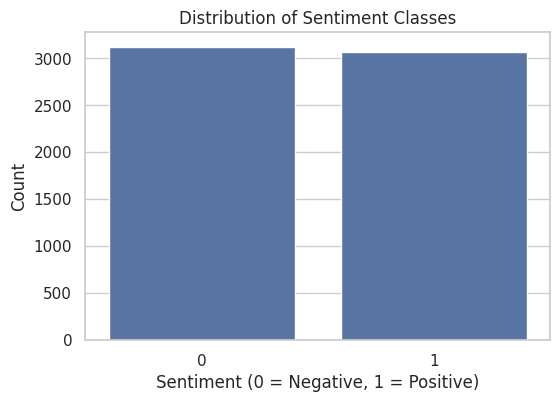

In [6]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment")
plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

## 2. Text Preprocessing

Required preprocessing for NLP:
- handle missing values
- clean text
- lowercase text
- remove HTML tags, punctuation, and extra spaces

Feature scaling is **not required** for raw text directly, but vectorized features are normalized by TF-IDF automatically.
One-hot encoding is **not required** because this dataset only contains text and a binary label.

In [7]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)            # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # keep letters and spaces
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,"Dumb is as dumb does, in this thoroughly unint...",dumb is as dumb does in this thoroughly uninte...,0
1,I dug out from my garage some old musicals and...,i dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,after watching this movie i was honestly disap...,0
3,This movie was nominated for best picture but ...,this movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,just like al gore shook us up with his painful...,1


In [8]:
# Split data
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 4955
Testing size: 1239


## 3. Feature Engineering

This section creates:
- Bag of Words vectors
- TF-IDF vectors
- Word embeddings with Word2Vec

In [9]:
# Bag of Words vectorization
bow_vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BOW train shape:", X_train_bow.shape)
print("BOW test shape:", X_test_bow.shape)

BOW train shape: (4955, 5000)
BOW test shape: (1239, 5000)


In [10]:
# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (4955, 5000)
TF-IDF test shape: (1239, 5000)


In [11]:
# Prepare tokenized text for word embeddings
tokenized_reviews = [text.split() for text in df["clean_review"]]

# Train Word2Vec embeddings
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv.index_to_key))
print("Sample similar words for 'good':")
print(w2v_model.wv.most_similar("good", topn=10) if "good" in w2v_model.wv else "Word not in vocabulary")

Vocabulary size: 14179
Sample similar words for 'good':
[('bad', 0.7717574834823608), ('great', 0.7482484579086304), ('decent', 0.7390767931938171), ('nice', 0.7375103235244751), ('funny', 0.7149978876113892), ('ok', 0.648209810256958), ('poor', 0.6266086101531982), ('scary', 0.6253116130828857), ('fine', 0.6204200983047485), ('cool', 0.6117094159126282)]


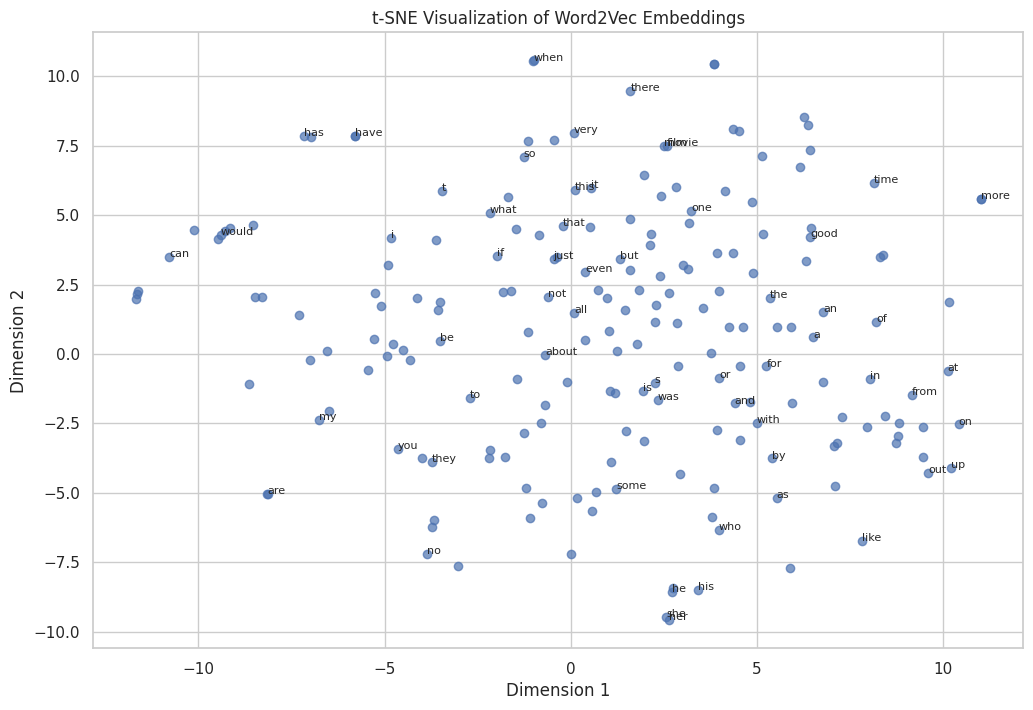

In [12]:
# Visualize word embeddings using t-SNE
words_to_plot = w2v_model.wv.index_to_key[:200]
word_vectors = np.array([w2v_model.wv[word] for word in words_to_plot])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
word_vectors_2d = tsne.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], alpha=0.7)

for i, word in enumerate(words_to_plot[:60]):  # label a smaller number to reduce clutter
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=8)

plt.title("t-SNE Visualization of Word2Vec Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

## 4. Traditional Machine Learning Models

The notebook trains at least two traditional classifiers:
- Logistic Regression
- Support Vector Machine (LinearSVC)

Grid search with cross-validation is used to optimize parameters.

In [13]:
# Logistic Regression pipeline with GridSearchCV
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1.0, 10.0]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

Best Logistic Regression parameters:
{'clf__C': 10.0, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}


In [14]:
# LinearSVC pipeline with GridSearchCV
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC())
])

svm_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1.0, 10.0]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best LinearSVC parameters:")
print(svm_grid.best_params_)

Best LinearSVC parameters:
{'clf__C': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}


In [15]:
# Predictions for traditional models
best_lr = lr_grid.best_estimator_
best_svm = svm_grid.best_estimator_

lr_pred = best_lr.predict(X_test)
lr_prob = best_lr.predict_proba(X_test)[:, 1]

svm_pred = best_svm.predict(X_test)
svm_scores = best_svm.decision_function(X_test)

In [16]:
# Evaluation function
def evaluate_model(y_true, y_pred, y_score=None, model_name="Model"):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }
    if y_score is not None:
        results["ROC-AUC"] = roc_auc_score(y_true, y_score)
    else:
        results["ROC-AUC"] = np.nan
    return results

traditional_results = []
traditional_results.append(evaluate_model(y_test, lr_pred, lr_prob, "Logistic Regression"))
traditional_results.append(evaluate_model(y_test, svm_pred, svm_scores, "LinearSVC"))

results_df = pd.DataFrame(traditional_results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.849879,0.850820,0.845277,0.848039,0.929290
1,LinearSVC,0.849879,0.834375,0.869707,0.851675,0.932164


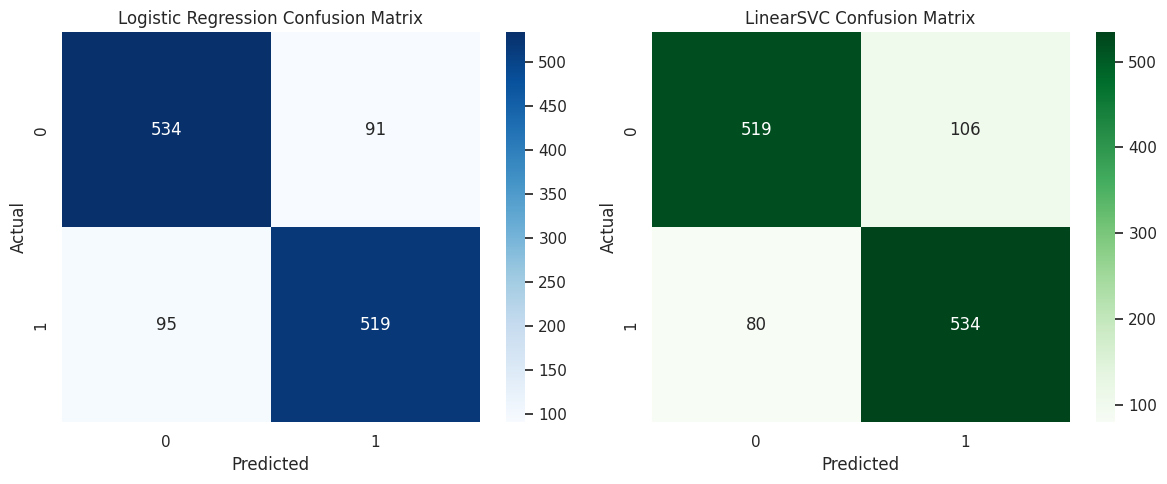

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("LinearSVC Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

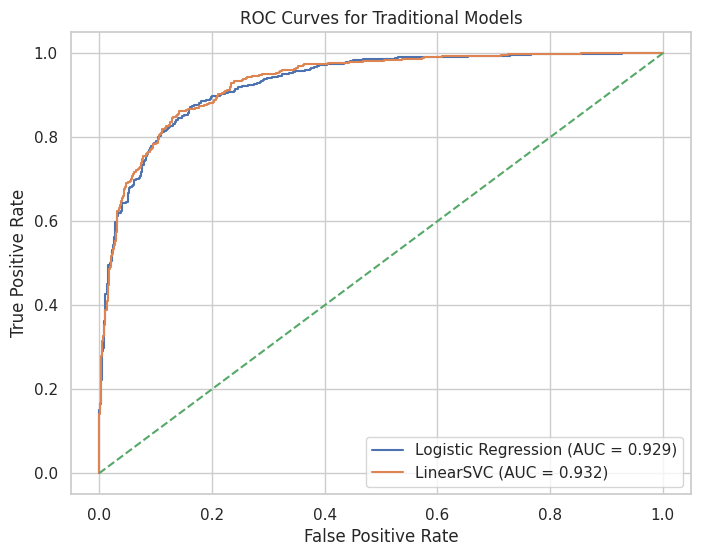

In [18]:
# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"LinearSVC (AUC = {roc_auc_score(y_test, svm_scores):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for Traditional Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [19]:
# Print classification reports
print("Logistic Regression Report\n")
print(classification_report(y_test, lr_pred))

print("\nLinearSVC Report\n")
print(classification_report(y_test, svm_pred))

Logistic Regression Report

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       625
           1       0.85      0.85      0.85       614

    accuracy                           0.85      1239
   macro avg       0.85      0.85      0.85      1239
weighted avg       0.85      0.85      0.85      1239


LinearSVC Report

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       625
           1       0.83      0.87      0.85       614

    accuracy                           0.85      1239
   macro avg       0.85      0.85      0.85      1239
weighted avg       0.85      0.85      0.85      1239



## 5. Sentiment Analysis Using BERT

This section fine-tunes a pre-trained BERT model from Hugging Face for binary sentiment classification.

To keep training practical in Google Colab, a smaller subset is used for fine-tuning.

In [20]:
# Create smaller BERT training and testing subsets for faster fine-tuning in Colab
bert_train_df = pd.DataFrame({"text": X_train, "label": y_train}).sample(1200, random_state=42)
bert_test_df = pd.DataFrame({"text": X_test, "label": y_test}).sample(400, random_state=42)

bert_train_df = bert_train_df.reset_index(drop=True)
bert_test_df = bert_test_df.reset_index(drop=True)

print(bert_train_df.shape, bert_test_df.shape)
bert_train_df.head()

(1200, 2) (400, 2)


,text,label
0,why do people who do not know what a particula...,0
1,i saw this film at a small screening even thou...,1
2,well first off if you re checking out revolt o...,0
3,i have always been a fan of the show so i ll a...,1
4,the movie has only one flaw unfortunately this...,0


In [21]:
from datasets import Dataset

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_test_dataset = Dataset.from_pandas(bert_test_df)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

bert_train_dataset = bert_train_dataset.map(tokenize_function, batched=True)
bert_test_dataset = bert_test_dataset.map(tokenize_function, batched=True)

bert_train_dataset = bert_train_dataset.remove_columns(["text"])
bert_test_dataset = bert_test_dataset.remove_columns(["text"])

bert_train_dataset.set_format("torch")
bert_test_dataset.set_format("torch")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
        "roc_auc": roc_auc_score(labels, probs)
    }

training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_test_dataset,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

In [24]:
# Fine-tune BERT
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.353742,0.311841,0.887500,0.893401,0.880000,0.886650,0.940325


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=150, training_loss=0.5267814127604167, metrics={'train_runtime': 3900.7624, 'train_samples_per_second': 0.308, 'train_steps_per_second': 0.038, 'total_flos': 157866633216000.0, 'train_loss': 0.5267814127604167, 'epoch': 1.0})

In [25]:
# Evaluate BERT
bert_eval = trainer.evaluate()
bert_eval

{'eval_loss': 0.31184113025665283,
 'eval_accuracy': 0.8875,
 'eval_precision': 0.8934010152284264,
 'eval_recall': 0.88,
 'eval_f1': 0.8866498740554156,
 'eval_roc_auc': 0.940325,
 'eval_runtime': 336.756,
 'eval_samples_per_second': 1.188,
 'eval_steps_per_second': 0.148,
 'epoch': 1.0}

In [26]:
# Get BERT predictions for plots
bert_predictions = trainer.predict(bert_test_dataset)
bert_logits = bert_predictions.predictions
bert_true = np.array(bert_test_df["label"])
bert_pred = np.argmax(bert_logits, axis=1)
bert_prob = torch.nn.functional.softmax(torch.tensor(bert_logits), dim=1)[:, 1].numpy()

bert_results = evaluate_model(bert_true, bert_pred, bert_prob, "BERT")
bert_results_df = pd.DataFrame([bert_results])
bert_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,BERT,0.8875,0.893401,0.88,0.88665,0.940325


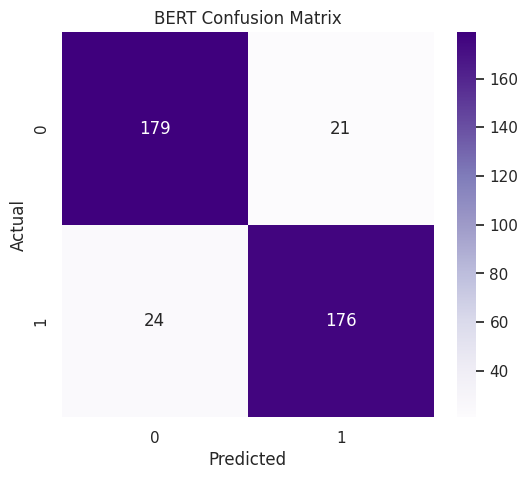

In [27]:
# BERT confusion matrix
cm_bert = confusion_matrix(bert_true, bert_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Purples")
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

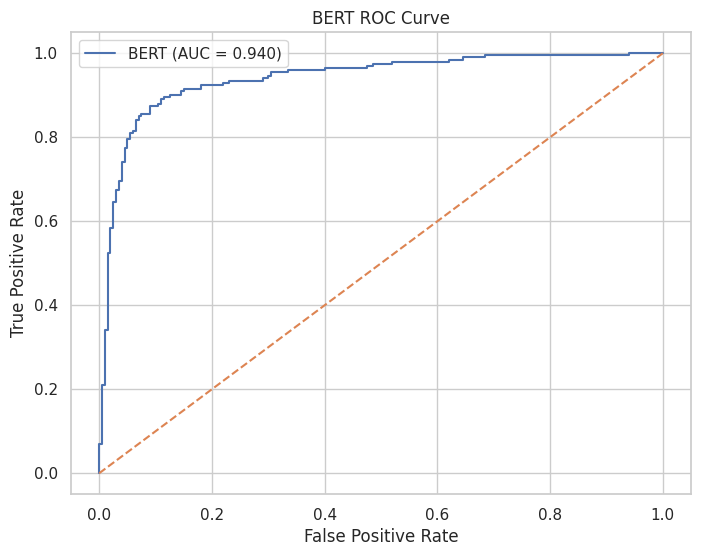

In [28]:
# BERT ROC curve
bert_fpr, bert_tpr, _ = roc_curve(bert_true, bert_prob)

plt.figure(figsize=(8, 6))
plt.plot(bert_fpr, bert_tpr, label=f"BERT (AUC = {roc_auc_score(bert_true, bert_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("BERT ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [29]:
# Combine all model results
all_results_df = pd.concat([results_df, bert_results_df], ignore_index=True)
all_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.849879,0.850820,0.845277,0.848039,0.929290
1,LinearSVC,0.849879,0.834375,0.869707,0.851675,0.932164
2,BERT,0.887500,0.893401,0.880000,0.886650,0.940325


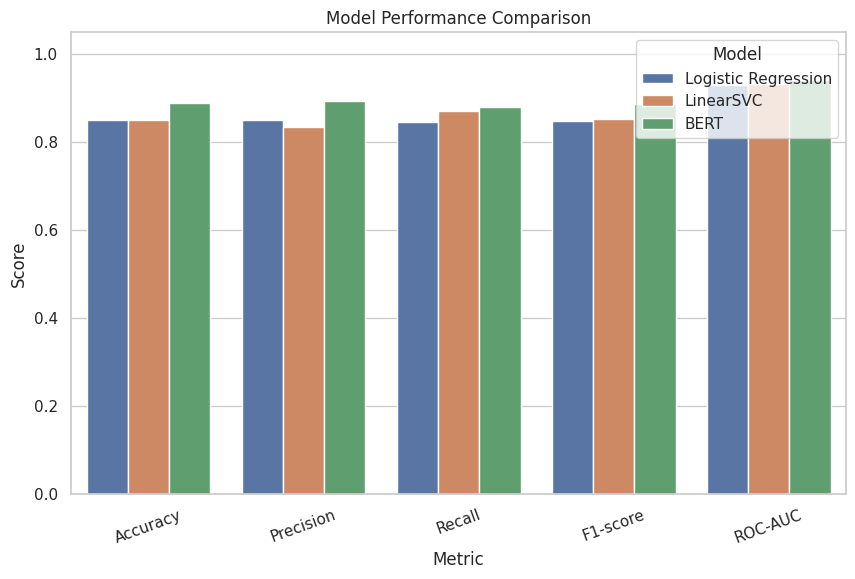

In [30]:
# Performance comparison chart
metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

all_results_melted = all_results_df.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=all_results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()